In [16]:
import pandas as pd 
import numpy as np
df = pd.read_csv(r"C:\Users\girid\Downloads\SuperStoreOrders.csv")

df.head()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [3]:
df["order_date"] = pd.to_datetime(df["order_date"], format='mixed', dayfirst=True)
df["ship_date"] = pd.to_datetime(df["ship_date"], format='mixed', dayfirst=True)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [11]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace=True)

In [18]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [13]:
df.to_csv("Cleaned_SuperStoreOrders.csv", index=False)

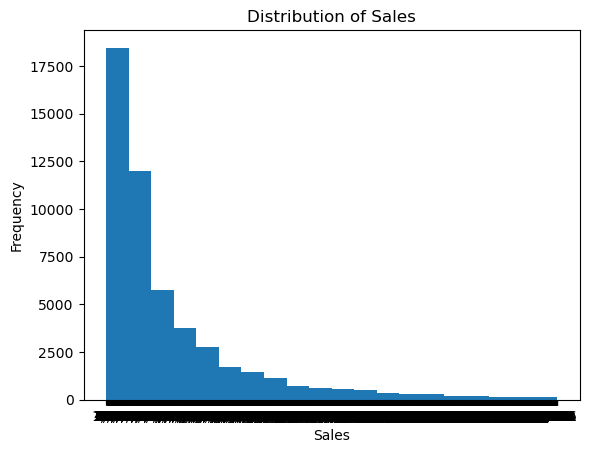

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.hist(df["sales"], bins=20)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

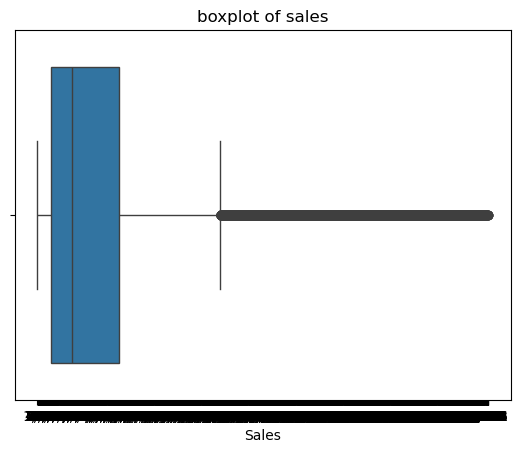

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.boxplot(x=df["sales"])
plt.title("boxplot of sales")
plt.xlabel("Sales")
plt.show()

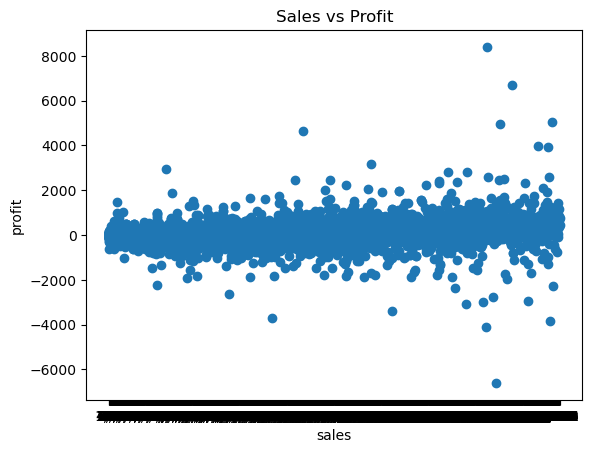

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(df["sales"], df["profit"])
plt.title("Sales vs Profit")
plt.xlabel("sales")
plt.ylabel("profit")    
plt.show()

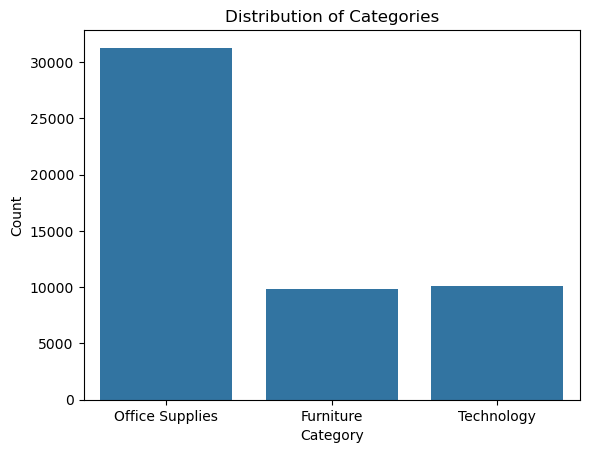

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=df["category"])
plt.title("Distribution of Categories") 
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

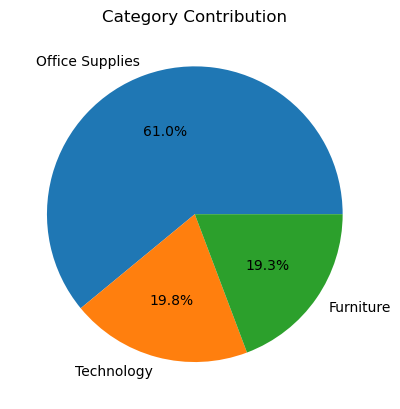

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
df["category"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Category Contribution")
plt.ylabel("")
plt.show()


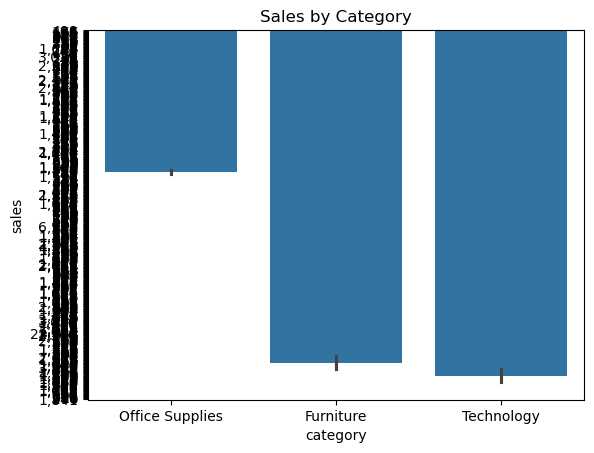

In [34]:
sns.barplot(x="category", y="sales", data=df)
plt.title("Sales by Category")
plt.show()


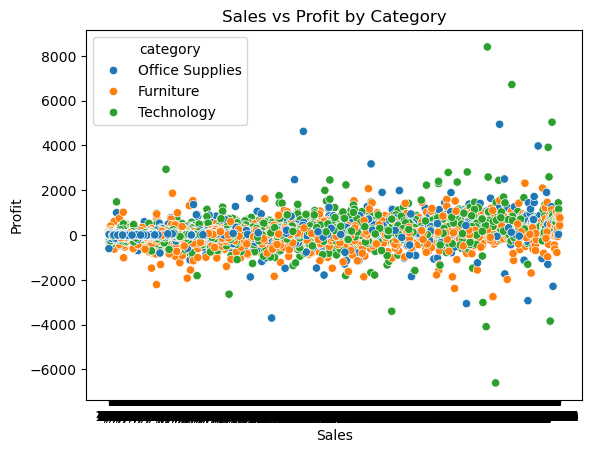

In [35]:
sns.scatterplot(x="sales", y="profit", hue="category", data=df)
plt.title("Sales vs Profit by Category")    
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

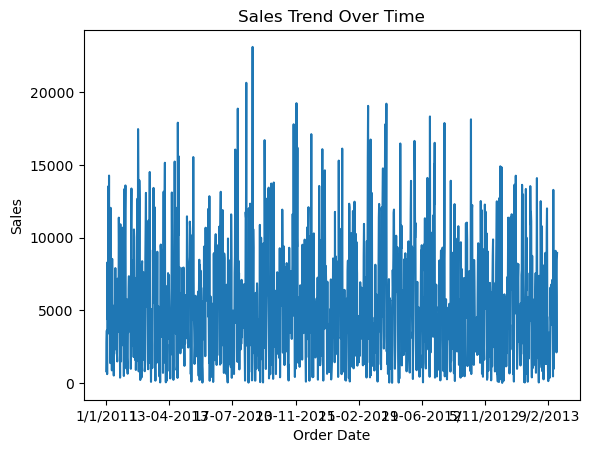

In [21]:
df["sales"] = pd.to_numeric(df["sales"], errors='coerce')
df.groupby("order_date")["sales"].sum().plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.show()


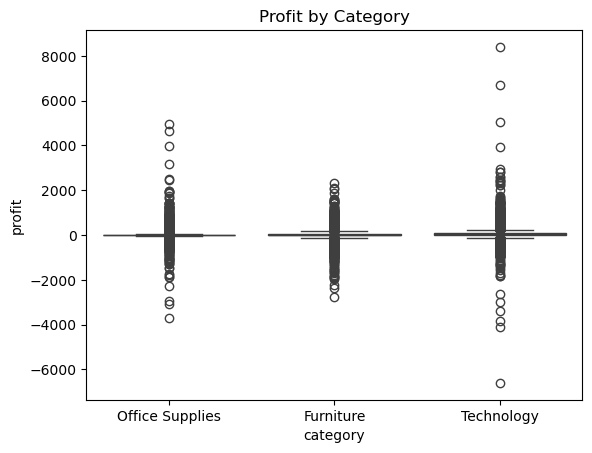

In [22]:
sns.boxplot(x="category", y="profit", data=df)
plt.title("Profit by Category")
plt.show()


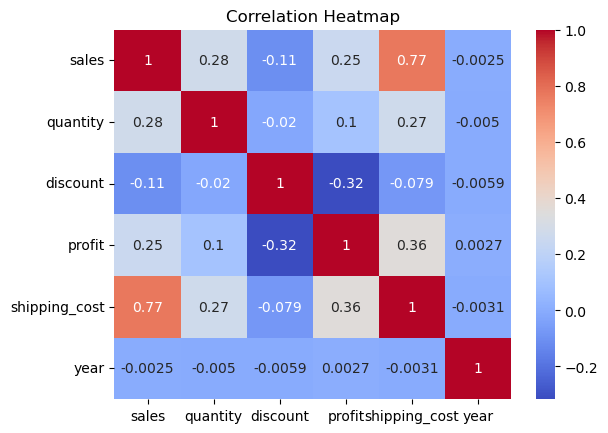

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


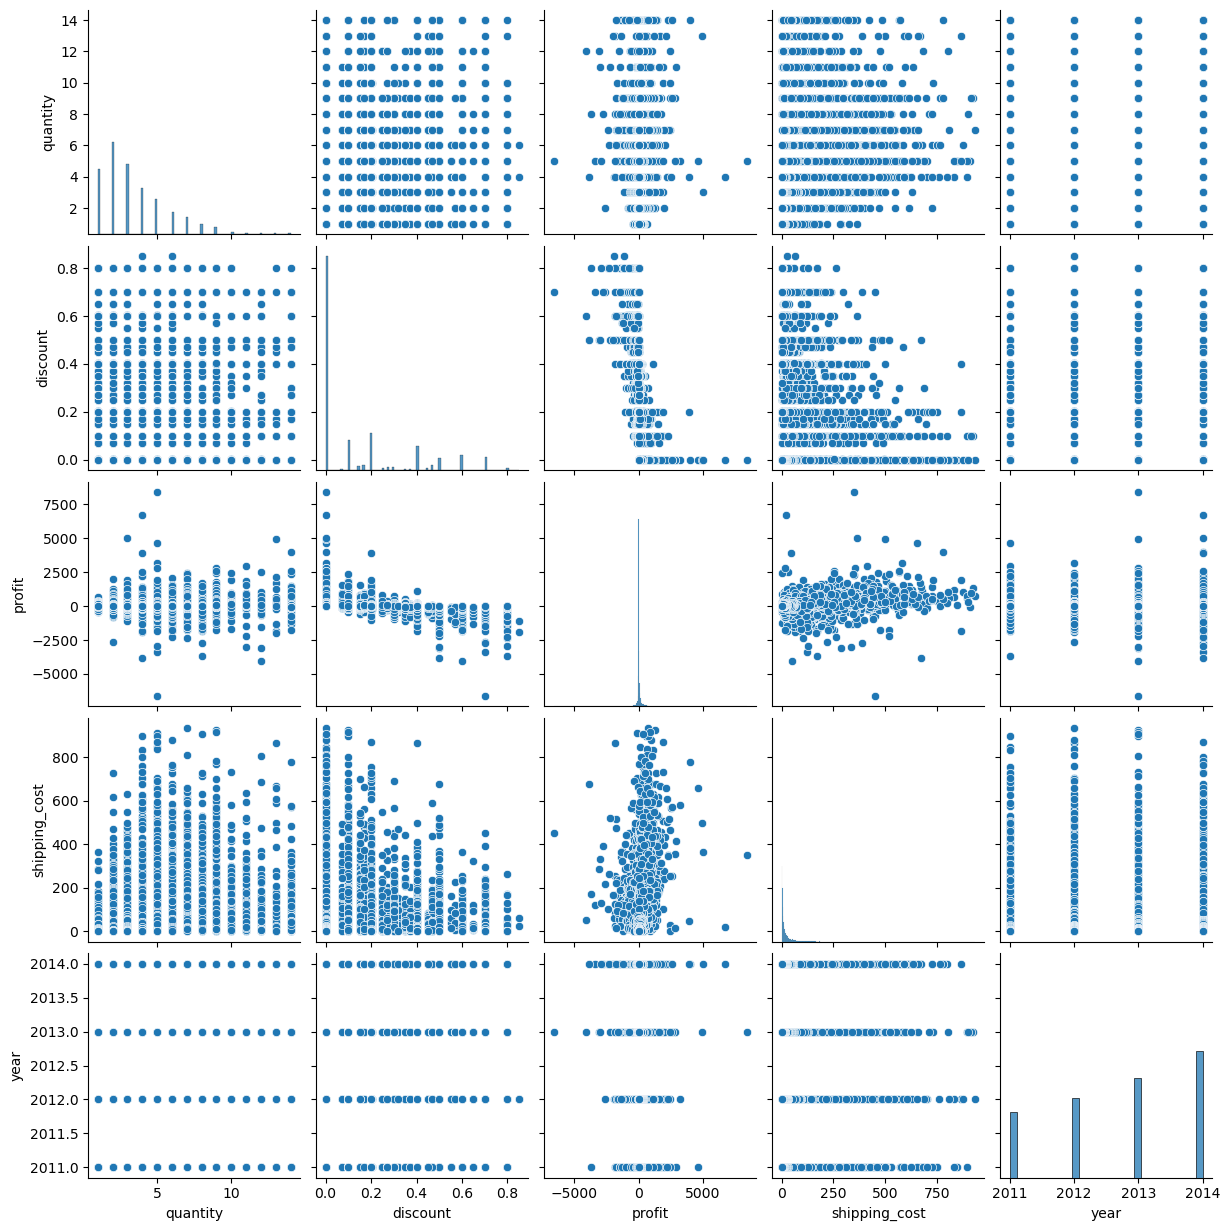

In [20]:
sns.pairplot(df)
plt.show()

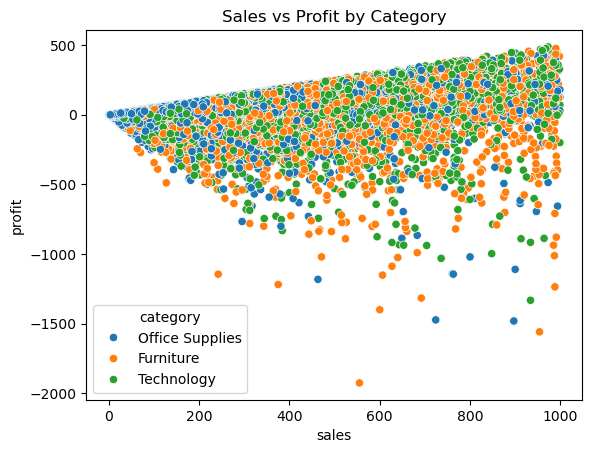

In [44]:
sns.scatterplot(x="sales", y="profit", hue="category", data=df)
plt.title("Sales vs Profit by Category")
plt.show()


C:\Users\girid\AppData\Local\Temp\ipykernel_12504\102842527.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample("M", on="order_date")["sales"].sum()


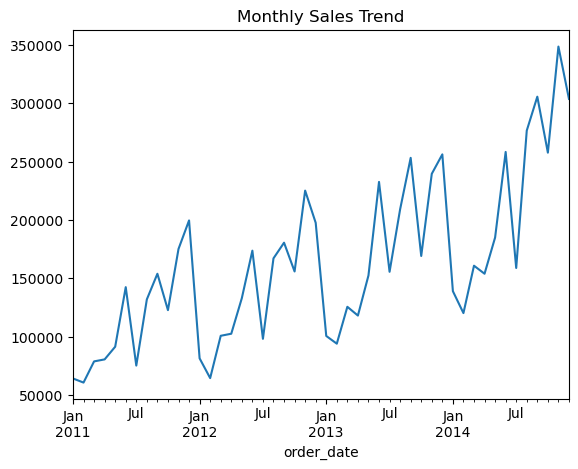

In [45]:
monthly_sales = df.resample("M", on="order_date")["sales"].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()


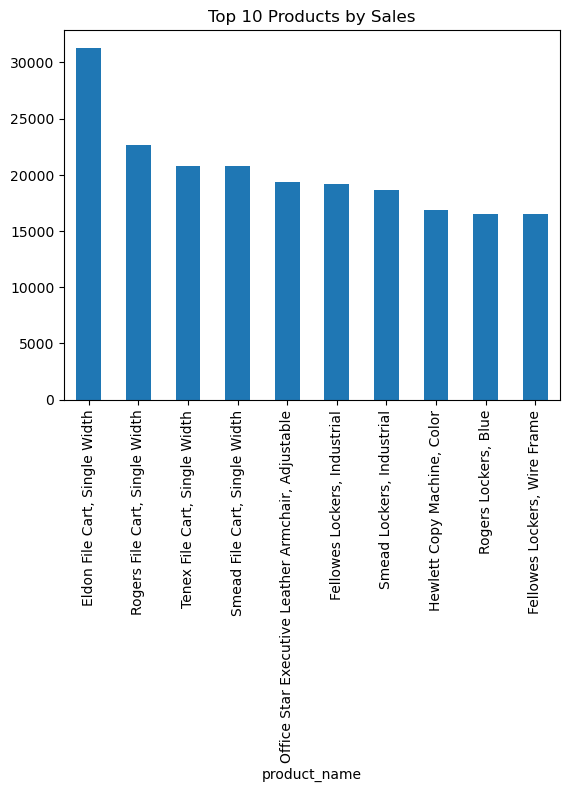

In [46]:
top_products = df.groupby("product_name")["sales"].sum().nlargest(10)

top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.show()


In [1]:
import sqlite3
import pandas as pd

# Load dataset
df = pd.read_csv("C:\data analytics task 2\Cleaned_SuperStoreOrders.csv")

# Create SQLite database
conn = sqlite3.connect("global_store.db")

# Push data into SQL table
df.to_sql("super_store_sales", conn, if_exists="replace", index=False)

print("Database connected successfully!")

Database connected successfully!
